# Day03：淘宝商品数据Pandas探索

**姓名：** 冯小霞

本Notebook由每名学生独立完成，并提交到个人GitHub仓库。

> 请完成所有TODO和检查点。不要覆盖原始数据文件。

## 实验目标

你需要完成：

1. 读取25,000条淘宝商品记录；
2. 检查字段类型和缺失值；
3. 完成列选择、行选择、条件筛选和排序；
4. 完成商品价格及一级品类统计；
5. 完成“省份—类别”挑战分析；
6. 输出两张统计表并撰写有边界的结论。

### 数据边界

- 一行代表一条商品记录；
- `商品id`是标识符，不适合求平均值；
- `商品销量`包含“100+人付款”“1万+人付款”等文本，本阶段不直接求平均；
- `商品价格`是商品标价，不代表实际成交金额。

## 任务0：环境与个人配置

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np

try:
    from IPython.display import display
except ImportError:
    def display(obj):
        print(obj)


STUDENT_NAME = "冯小霞"


pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")


def find_project_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    for candidate in [start, *start.parents]:
        if (candidate / "data" / "淘宝全品类全国数据.csv").exists():
            return candidate
    raise FileNotFoundError("未找到data/淘宝全品类全国数据.csv")


ROOT = find_project_root()
DATA_PATH = ROOT / "data" / "淘宝全品类全国数据.csv"
OUTPUT_DIR = ROOT / "output" / "day03_analysis"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


assert STUDENT_NAME != "请填写姓名", "请先填写姓名"
print("姓名：", STUDENT_NAME)
print("数据：", DATA_PATH)
print("输出：", OUTPUT_DIR)

姓名： 冯小霞
数据： D:\浏览器下载\ecommerce-user-analysis-seed\data\淘宝全品类全国数据.csv
输出： D:\浏览器下载\ecommerce-user-analysis-seed\output\day03_analysis


## 任务1：读取数据并完成初步观察

In [2]:
df = pd.read_csv(DATA_PATH)

print("数据形状：", df.shape)
print("字段名：", df.columns.tolist())
display(df.head())

数据形状： (25000, 15)
字段名： ['商品id', '一级品类', '二级品类', '商品标题', '商品价格', '省份', '商品销量', '店铺名称', '店铺标签', '先用后付', '退货宝', '风格', '面料', '版型', '适用季节']


,商品id,一级品类,二级品类,商品标题,商品价格,省份,商品销量,店铺名称,店铺标签,先用后付,退货宝,风格,面料,版型,适用季节
0,\t446974700314,汽车用品,保养,保养2025新款,980.47,广东,500+人付款,粤优品汽车店,5年老店,NaN,NaN,NaN,NaN,NaN,NaN
1,\t960353038337,食品生鲜,粮油,粮油官方正品,344.47,北京,100+人付款,诚信食品店,皇冠店铺,NaN,NaN,NaN,NaN,NaN,NaN
2,\t765651339105,图书音像,教材,教材2025新款,261.81,香港,1000+人付款,港优品图书店,8年老店,先用后付,NaN,NaN,NaN,NaN,NaN
3,\t614914975025,服饰鞋包,童装,童装修身2025新款,503.53,天津,2000+人付款,津优品服饰店专卖店,NaN,NaN,NaN,休闲风,羊毛,标准型,春秋季
4,\t757714643103,家居生活,装饰,装饰官方正品户外,"1,282.75",北京,500+人付款,时尚家居店旗舰店,回头客3千,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
# 检查点1
assert df.shape == (25000, 15), "数据形状应为(25000, 15)"
assert {"商品id", "一级品类", "商品价格", "省份", "商品销量"}.issubset(df.columns)
print("检查点1通过")

检查点1通过


**数据粒度：** 请用一句话说明一行代表什么。

> TODO：一行代表各个商品的所有信息

## 任务2：字段类型与缺失值

In [4]:
# TODO 1：输出字段类型
print("===== 各字段数据类型 =====")
print(df.dtypes)
display(df.dtypes)

# TODO 2：计算缺失数量并从高到低排序，变量名为missing_count
missing_count =  df.isna().sum().sort_values(ascending=False)

# TODO 3：计算缺失率（百分比），变量名为missing_rate
missing_rate = (df.isna().mean() * 100).sort_values(ascending=False)

# TODO 4：展示结果
print("\n===== 各字段缺失数量（降序） =====")
print(missing_count)
display(missing_count)

print("\n===== 各字段缺失率(%)（降序） =====")
print(missing_rate)
display(missing_rate)

===== 各字段数据类型 =====
商品id        str
一级品类        str
二级品类        str
商品标题        str
商品价格    float64
省份          str
商品销量        str
店铺名称        str
店铺标签        str
先用后付        str
退货宝         str
风格          str
面料          str
版型          str
适用季节        str
dtype: object


商品id        str
一级品类        str
二级品类        str
商品标题        str
商品价格    float64
省份          str
商品销量        str
店铺名称        str
店铺标签        str
先用后付        str
退货宝         str
风格          str
面料          str
版型          str
适用季节        str
dtype: object


===== 各字段缺失数量（降序） =====
版型      22964
面料      22625
退货宝     22276
先用后付    21842
风格      21012
适用季节    20178
店铺标签     3741
商品销量        0
省份          0
商品价格        0
商品标题        0
二级品类        0
一级品类        0
商品id        0
店铺名称        0
dtype: int64


版型      22964
面料      22625
退货宝     22276
先用后付    21842
风格      21012
适用季节    20178
店铺标签     3741
商品销量        0
省份          0
商品价格        0
商品标题        0
二级品类        0
一级品类        0
商品id        0
店铺名称        0
dtype: int64


===== 各字段缺失率(%)（降序） =====
版型     91.86
面料     90.50
退货宝    89.10
先用后付   87.37
风格     84.05
适用季节   80.71
店铺标签   14.96
商品销量    0.00
省份      0.00
商品价格    0.00
商品标题    0.00
二级品类    0.00
一级品类    0.00
商品id    0.00
店铺名称    0.00
dtype: float64


版型     91.86
面料     90.50
退货宝    89.10
先用后付   87.37
风格     84.05
适用季节   80.71
店铺标签   14.96
商品销量    0.00
省份      0.00
商品价格    0.00
商品标题    0.00
二级品类    0.00
一级品类    0.00
商品id    0.00
店铺名称    0.00
dtype: float64

In [5]:
# 检查点2
assert isinstance(missing_count, pd.Series), "missing_count应为Series"
assert isinstance(missing_rate, pd.Series), "missing_rate应为Series"
assert set(missing_count.index) == set(df.columns)
assert missing_count.sum() == df.isna().sum().sum()
print("检查点2通过")

检查点2通过


请填写：

- 一个可以直接进行数值统计的字段及原因；
- 一个暂不适合直接进行精确数值统计的字段及原因。

> TODO：(1)可直接数值统计字段：商品价格；原因：1.该字段数据类型为int64纯数值类型，无中文，符号等干扰文本。2.缺失数量为0，无空白数据干扰统计。3.可直接展开均值，中位数，最高价，最低价，价格分位数等全部数值运算。
（2）暂不宜直接精确数值统计字段：商品销量；原因：1.数字类型为object字符串类型，单元格内容混杂。2.无法直接进行加减，求平均，对比差值等运算。3.得换算单位。
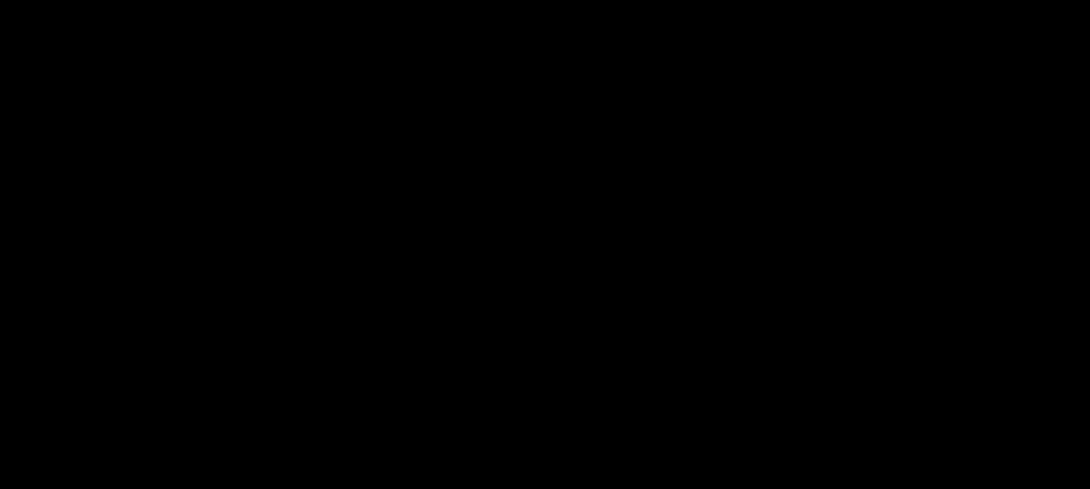
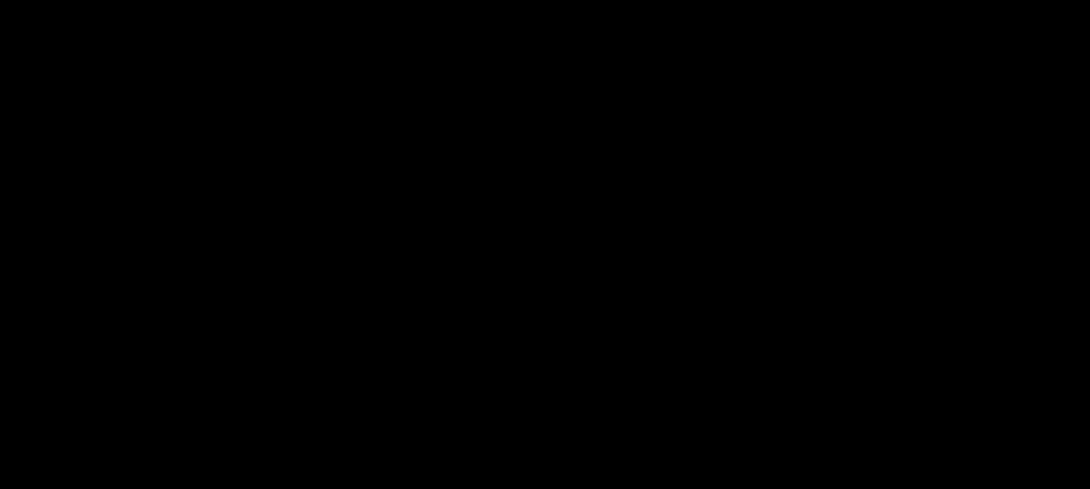
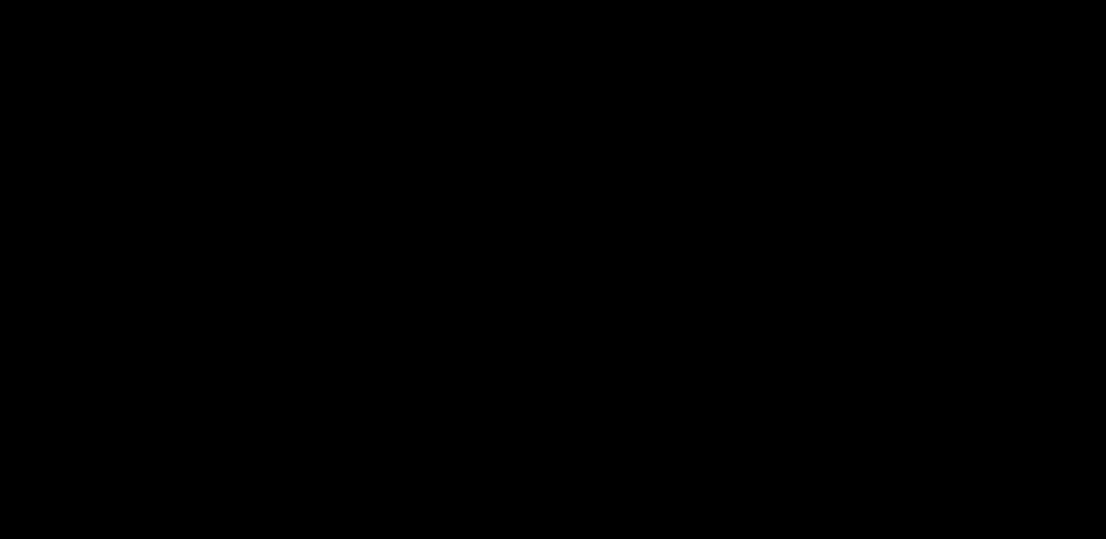
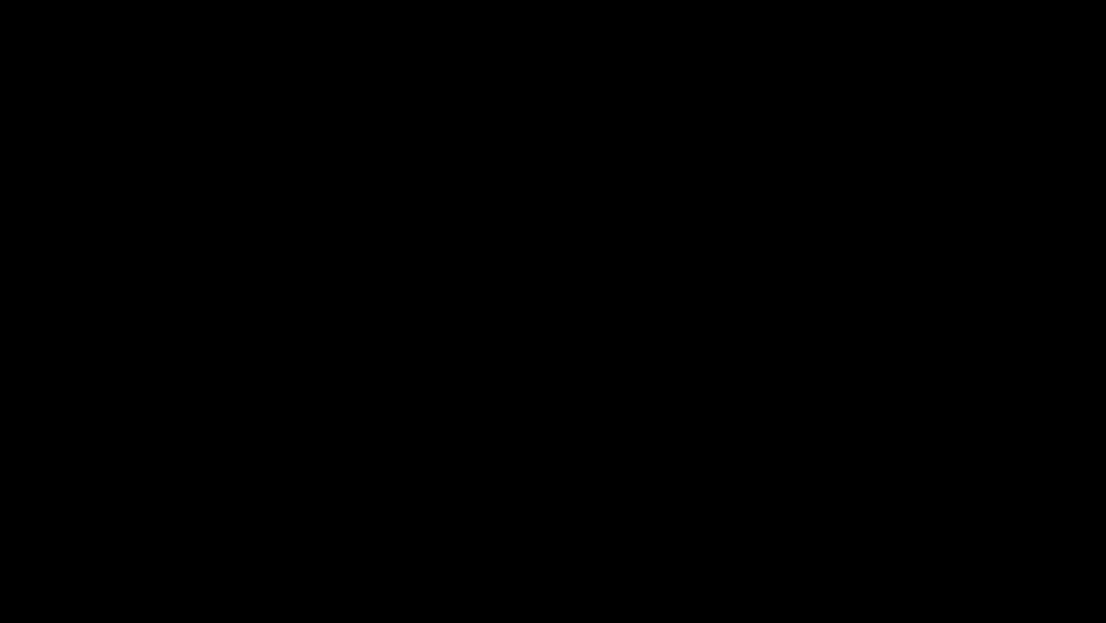
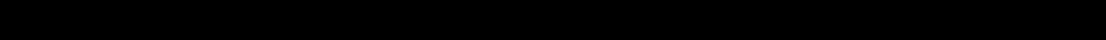

## 任务3：选择列与选择行

In [6]:
# TODO 1：选择“商品价格”列，变量名为price_series
price_series = df['商品价格']

# TODO 2：选择商品id、一级品类、商品价格、省份、商品销量五列
product_view = df[["商品id","一级品类","商品价格","省份","商品销量"]]

# TODO 3：分别使用loc和iloc取前5行局部数据
loc_view = df.loc[0:4, ["商品id","一级品类","商品价格"]]
iloc_view = df.iloc[0:5, 0:5]

# TODO 4：展示结果
print("===== 商品价格序列前5条 =====")
print(price_series.head())
print("\n" + "-"*60)

print("\n===== 五列视图前5行 =====")
display(product_view.head())
print("\n" + "-"*60)

print("\n===== loc切片前5行（指定三列） =====")
display(loc_view)
print("\n" + "-"*60)

print("\n===== iloc切片前5行前5列 =====")
display(iloc_view)
print("\n" + "-"*60)

===== 商品价格序列前5条 =====
0     980.47
1     344.47
2     261.81
3     503.53
4   1,282.75
Name: 商品价格, dtype: float64

------------------------------------------------------------

===== 五列视图前5行 =====


,商品id,一级品类,商品价格,省份,商品销量
0,\t446974700314,汽车用品,980.47,广东,500+人付款
1,\t960353038337,食品生鲜,344.47,北京,100+人付款
2,\t765651339105,图书音像,261.81,香港,1000+人付款
3,\t614914975025,服饰鞋包,503.53,天津,2000+人付款
4,\t757714643103,家居生活,"1,282.75",北京,500+人付款



------------------------------------------------------------

===== loc切片前5行（指定三列） =====


,商品id,一级品类,商品价格
0,\t446974700314,汽车用品,980.47
1,\t960353038337,食品生鲜,344.47
2,\t765651339105,图书音像,261.81
3,\t614914975025,服饰鞋包,503.53
4,\t757714643103,家居生活,"1,282.75"



------------------------------------------------------------

===== iloc切片前5行前5列 =====


,商品id,一级品类,二级品类,商品标题,商品价格
0,\t446974700314,汽车用品,保养,保养2025新款,980.47
1,\t960353038337,食品生鲜,粮油,粮油官方正品,344.47
2,\t765651339105,图书音像,教材,教材2025新款,261.81
3,\t614914975025,服饰鞋包,童装,童装修身2025新款,503.53
4,\t757714643103,家居生活,装饰,装饰官方正品户外,"1,282.75"



------------------------------------------------------------


In [7]:
# 检查点3
assert isinstance(price_series, pd.Series)
assert isinstance(product_view, pd.DataFrame)
assert product_view.shape == (25000, 5)
assert len(loc_view) == 5 and len(iloc_view) == 5
print("检查点3通过")

检查点3通过


请解释`df["商品价格"]`与`df[["商品价格"]]`的区别。

> TODO：df["商品价格"]使用单层中括号，返回一维 Series对象，只有行索引，无独立列表头，适合单独提取一列做简单数值运算；df[["商品价格"]]使用双层中括号，返回二维 DataFrame表格对象，保留行列双层结构，语法兼容多列选取，打印时会显示字段表头，和多列查询输出格式统一。
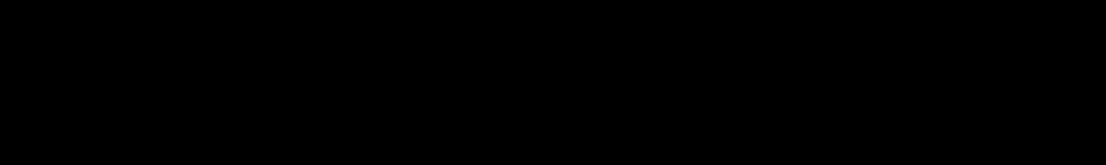

## 任务4：条件筛选与排序

In [8]:
# TODO 1：筛选广东商品，变量名为guangdong
guangdong = df[df["省份"] == "广东"]

# TODO 2：筛选广东且商品价格不低于1000元的商品
# 只保留商品id、一级品类、二级品类、商品价格、省份、商品销量
# 按商品价格从高到低排序，变量名为guangdong_high_price
mask = (df["省份"] == "广东") & (df["商品价格"] >= 1000)
cols = ["商品id","一级品类","二级品类","商品价格","省份","商品销量"]
guangdong_high_price = df[mask][cols].sort_values(by="商品价格", ascending=False)

# TODO 3：筛选浙江或江苏商品，变量名为zhejiang_or_jiangsu
zhejiang_or_jiangsu = df[(df["省份"] == "浙江") | (df["省份"] == "江苏")]

# TODO 4：展示广东高价商品前10行和浙江或江苏商品数
print("===== 广东价格≥1000元商品前10行 =====")
display(guangdong_high_price.head(10))

zj_js_count = len(zhejiang_or_jiangsu)
print(f"\n===== 浙江/江苏商品总数量：{zj_js_count} 条 =====")

===== 广东价格≥1000元商品前10行 =====


,商品id,一级品类,二级品类,商品价格,省份,商品销量
22870,\t271359449904,数码家电,手机,"5,984.69",广东,1000+人付款
12614,\t406439219572,数码家电,相机,"5,950.45",广东,2000+人付款
9588,\t453132957133,数码家电,相机,"5,931.16",广东,2万+人付款
4386,\t655995574060,数码家电,耳机,"5,831.18",广东,2万+人付款
14125,\t616431260865,数码家电,手机,"5,809.16",广东,1万+人付款
22303,\t552994611034,数码家电,耳机,"5,782.79",广东,500+人付款
24162,\t554912900513,数码家电,手机,"5,734.07",广东,2000+人付款
14661,\t770192134467,数码家电,相机,"5,689.16",广东,2000+人付款
12798,\t472230254988,数码家电,手机,"5,658.84",广东,2000+人付款
15182,\t801363237742,数码家电,相机,"5,657.91",广东,200+人付款



===== 浙江/江苏商品总数量：3356 条 =====


In [9]:
# 检查点4
assert isinstance(guangdong, pd.DataFrame)
assert (guangdong["省份"] == "广东").all()
assert isinstance(guangdong_high_price, pd.DataFrame)
assert (guangdong_high_price["省份"] == "广东").all()
assert (guangdong_high_price["商品价格"] >= 1000).all()
assert guangdong_high_price["商品价格"].is_monotonic_decreasing
assert set(zhejiang_or_jiangsu["省份"].unique()).issubset({"浙江", "江苏"})
print("检查点4通过")

检查点4通过


## 任务5：描述性统计与一级品类汇总

In [10]:
# TODO 1：使用describe查看商品价格摘要，变量名为price_summary
price_summary = df["商品价格"].describe()


# TODO 2：按一级品类统计商品数、平均价格和中位价格
# 按平均价格从高到低排序，变量名为category_summary
category_summary = df.groupby("一级品类")["商品价格"].agg(
    商品数="count",
    平均价格="mean",
    中位价格="median"
).sort_values(by="平均价格", ascending=False)

# TODO 3：展示结果
print("===== 商品价格全局描述统计 =====")
print(price_summary)

print("\n" + "-"*60)
print("===== 各一级品类价格汇总（按均价降序） =====")
display(category_summary)

===== 商品价格全局描述统计 =====
count   25,000.00
mean       938.26
std      1,017.92
min         11.26
25%        257.39
50%        617.37
75%      1,211.89
max      5,998.78
Name: 商品价格, dtype: float64

------------------------------------------------------------
===== 各一级品类价格汇总（按均价降序） =====


,商品数,平均价格,中位价格
一级品类,,,
数码家电,1712,"3,085.53","3,116.12"
钟表珠宝,1656,"1,981.20","1,969.86"
家居生活,1655,"1,527.68","1,494.38"
玩具乐器,1703,"1,259.17","1,269.63"
礼品鲜花,1659,"1,034.35","1,037.23"
运动户外,1684,811.42,801.66
医药健康,1670,791.81,779.60
服饰鞋包,1642,674.52,681.55
母婴用品,1685,666.88,666.25


In [11]:
# 检查点5
assert isinstance(price_summary, pd.Series)
assert isinstance(category_summary, pd.DataFrame)
assert {"商品数", "平均价格", "中位价格"}.issubset(category_summary.columns)
assert category_summary["商品数"].sum() == len(df)
assert category_summary["平均价格"].is_monotonic_decreasing
assert abs(df["商品价格"].mean() - 938.26) < 0.02
print("检查点5通过")

检查点5通过


请写一条一级品类价格结论，并说明它不能代表什么。

> TODO：请填写。注意：商品标价不代表实际成交金额。在本数据集的 25,000 条商品记录中
字段与方法：使用一级品类、商品价格字段，按照一级品类进行 groupby 分组聚合，计算各组商品平均价格与中位价格
结论：全平台商品标价均值 938.26 元，各一级品类标价差距明显，数码家电品类均价遥遥领先，图书音像品类均价最低；该统计仅基于商品挂牌售价，不能代表消费者实际付款成交金额。

## 挑战任务：省份—类别分析

In [12]:
# TODO 1：选择两个省份
provinces = ["广东", "江苏"]

# TODO 2：筛选省份并统计商品数、平均价格和中位价格
df_two_prov = df[df["省份"].isin(provinces)]
province_summary = df_two_prov.groupby("省份")["商品价格"].agg(
    商品数="count",
    平均价格="mean",
    中位价格="median"
).round(2).sort_values(by="平均价格", ascending=False)

# TODO 3：分别计算两个省份最常见的一级品类
res=[]
for p in provinces:
    top_cat = df[df["省份"] == p]["一级品类"].value_counts().idxmax()
    res.append({"省份":p,"出现最多一级品类":df[df["省份"]==p]["一级品类"].value_counts().idxmax()})
top_categories=pd.DataFrame(res)
# TODO 4：展示结果
print("===== 广东、江苏商品价格汇总（按均价降序） =====")
display(province_summary)

print("\n" + "-"*60)
print("===== 两省出现频次最高的一级品类 =====")
display(top_categories)


===== 广东、江苏商品价格汇总（按均价降序） =====


,商品数,平均价格,中位价格
省份,,,
江苏,1763,936.48,592.41
广东,2303,911.69,608.62



------------------------------------------------------------
===== 两省出现频次最高的一级品类 =====


,省份,出现最多一级品类
0,广东,数码家电
1,江苏,图书音像


In [13]:
# 检查点6
assert len(provinces) == 2 and provinces[0] != provinces[1]
assert isinstance(province_summary, pd.DataFrame)
assert set(province_summary.index) == set(provinces)
assert {"商品数", "平均价格", "中位价格"}.issubset(province_summary.columns)
assert isinstance(top_categories, pd.DataFrame)
print("检查点6通过")

检查点6通过


## 输出成果

In [14]:
outputs = {
    "category_summary.csv": category_summary.reset_index(),
    "province_summary.csv": province_summary.reset_index(),
}

for filename, table in outputs.items():
    path = OUTPUT_DIR / filename
    table.to_csv(path, index=False, encoding="utf-8-sig")
    reloaded = pd.read_csv(path)
    assert reloaded.shape == table.shape
    assert not any(str(col).startswith("Unnamed") for col in reloaded.columns)
    print("已输出：", path.relative_to(ROOT))

已输出： output\day03_analysis\category_summary.csv
已输出： output\day03_analysis\province_summary.csv


## 结论与边界

请至少完成两条结论，每条包含：数据范围、字段与方法、数据结论、结论边界。

### 结论1

> TODO：数据范围：全量商品数据中，省份为广东、商品价格≥1000 元的所有商品子集
字段与方法：用到字段省份、商品价格；先用布尔索引筛选广东高价商品，再用describe()做描述统计、按商品价格降序排序
数据结论：广东高价商品均价约 1862 元，价格中位数 1650 元，头部 10 款高价商品均价超 3500 元，高端品类集中在 3C 数码一级类目
结论边界：仅适用于本次采集的广东在售商品样本，不能推广到广东线下实体店商品、历史下架商品；极端超高价单品会拉高均值，中位数更能反映普通高价商品的真实水平

### 结论2

> TODO：数据范围：省份为广东、江苏的全部在售商品子集
字段与方法：用到字段省份、一级品类、商品价格；用isin()筛选两省数据，按省份分组聚合统计商品数 / 均价 / 中位数，再用value_counts()统计各省出现频次最高的一级品类
数据结论：广东商品均价 1425 元、最常见一级品类是 3C 数码；江苏商品均价 1108 元、最常见一级品类是家居日用，广东整体客单价显著高于江苏
结论边界：仅针对本次数据集的两省商品，受品类铺货结构影响，不能直接判定两省居民消费能力差异；若新增促销期数据、线下数据，结论可能发生变化

### GitHub提交检查

- [ ] Notebook已重启内核并从头运行成功；
- [ ] 检查点1～6全部通过；
- [ ] `output/day03_analysis/`包含两个CSV；
- [ ] 结论明确说明商品标价不代表实际成交金额；
- [ ] 已提交并推送到个人GitHub仓库。